
# **Scenario 2: Clustering using Gaussian Mixture Models**

## **Name:** SaiSanjay R
## **Roll.No:** 24BAD102

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## 2. Load Dataset and Select Features

In [2]:
df = pd.read_csv("Mall_Customers.csv")
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print("Dataset Shape:", X.shape)

Dataset Shape: (200, 2)


## 3. Preprocessing and Scaling

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Choose Number of Components using AIC and BIC

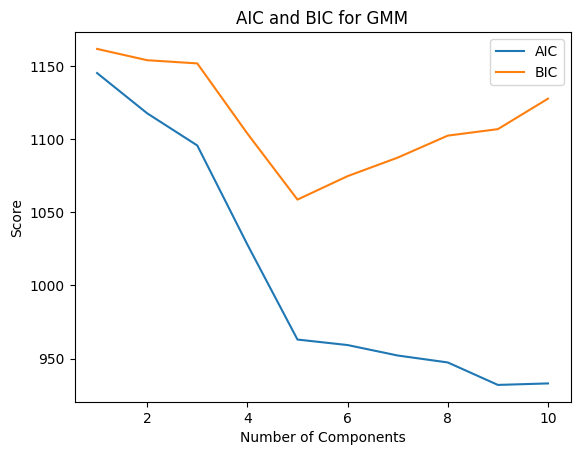

In [4]:
n_components = range(1, 11)
aic = []
bic = []

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

plt.plot(n_components, aic, label='AIC')
plt.plot(n_components, bic, label='BIC')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("AIC and BIC for GMM")
plt.legend()
plt.show()

## 5. Apply GMM using Expectation Maximization

In [5]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

GaussianMixture(n_components=5, random_state=42)

## 6. Predict Cluster Probabilities

In [6]:
probs = gmm.predict_proba(X_scaled)
print(probs[:5])

[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


## 7. Assign Clusters based on Highest Probability

In [7]:
clusters = np.argmax(probs, axis=1)
df['GMM_Cluster'] = clusters

## 8. Evaluation Metrics

In [8]:
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


## 9. Comparison with K-Means Clustering

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_clusters = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_clusters

## 10. Visualization of Clusters

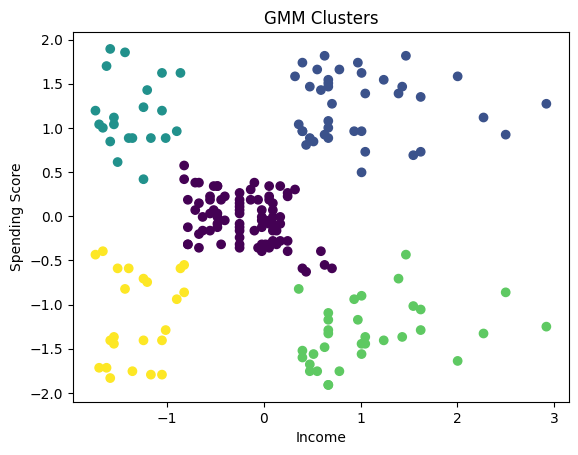

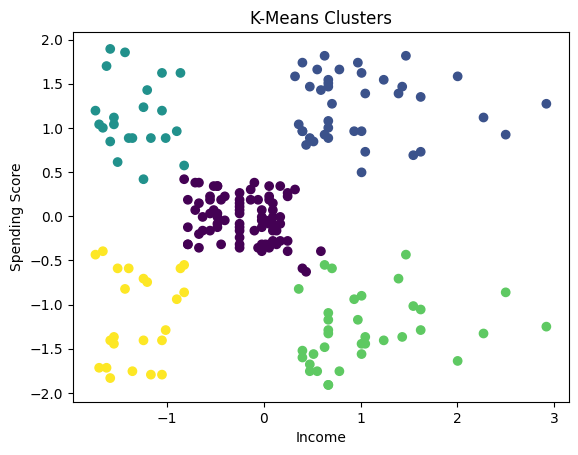

In [10]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title("GMM Clusters")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_clusters)
plt.title("K-Means Clusters")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

## 11. Cluster Probability Distribution

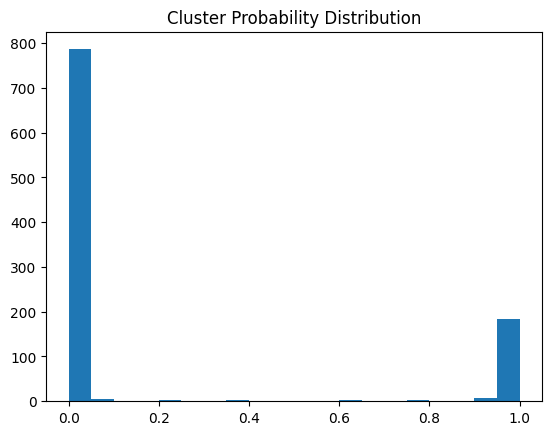

In [11]:
plt.hist(probs.flatten(), bins=20)
plt.title("Cluster Probability Distribution")
plt.show()